In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

os.makedirs('charts', exist_ok=True)

In [2]:
df = pd.read_csv('train.csv', encoding='latin-1')

# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

# Time features
df['Year']      = df['Order Date'].dt.year
df['Month']     = df['Order Date'].dt.month
df['Week']      = df['Order Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Quarter']   = df['Order Date'].dt.quarter
df['Season']    = df['Month'].map({12:'Winter',1:'Winter',2:'Winter',
                                    3:'Spring',4:'Spring',5:'Spring',
                                    6:'Summer',7:'Summer',8:'Summer',
                                    9:'Autumn',10:'Autumn',11:'Autumn'})
df['ShipLag']   = (df['Ship Date'] - df['Order Date']).dt.days

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (9800, 25)

Missing values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
DayOfWeek         0
Quarter           0
Season            0
ShipLag           0
dtype: int64

Duplicates: 0


In [3]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

weekly_sales = df.groupby(df['Order Date'].dt.to_period('W'))['Sales'].sum().reset_index()
weekly_sales['Order Date'] = weekly_sales['Order Date'].dt.to_timestamp()

print("Monthly sales shape:", monthly_sales.shape)
print(monthly_sales.head())

Monthly sales shape: (48, 2)
  Order Date      Sales
0 2015-01-01  14205.707
1 2015-02-01   4519.892
2 2015-03-01  55205.797
3 2015-04-01  27906.855
4 2015-05-01  23644.303


In [4]:
# Q1: Highest revenue category
cat_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Revenue by Category:\n", cat_revenue)

# Q2: Region with most consistent growth
region_yearly = df.groupby(['Region','Year'])['Sales'].sum().unstack()
print("\nYearly Sales by Region:\n", region_yearly)

# Q3: Avg ship lag by region
ship_lag = df.groupby('Region')['ShipLag'].mean().round(2)
print("\nAvg Ship Lag by Region (days):\n", ship_lag)

# Q4: Monthly seasonality
monthly_avg = df.groupby('Month')['Sales'].mean().round(2)
print("\nAvg Sales by Month:\n", monthly_avg)

Revenue by Category:
 Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Yearly Sales by Region:
 Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255

Avg Ship Lag by Region (days):
 Region
Central    4.07
East       3.91
South      3.96
West       3.93
Name: ShipLag, dtype: float64

Avg Sales by Month:
 Month
1     257.63
2     199.90
3     290.55
4     207.43
5     212.53
6     211.05
7     208.80
8     227.01
9     221.64
10    246.60
11    241.66
12    232.62
Name: Sales, dtype: float64


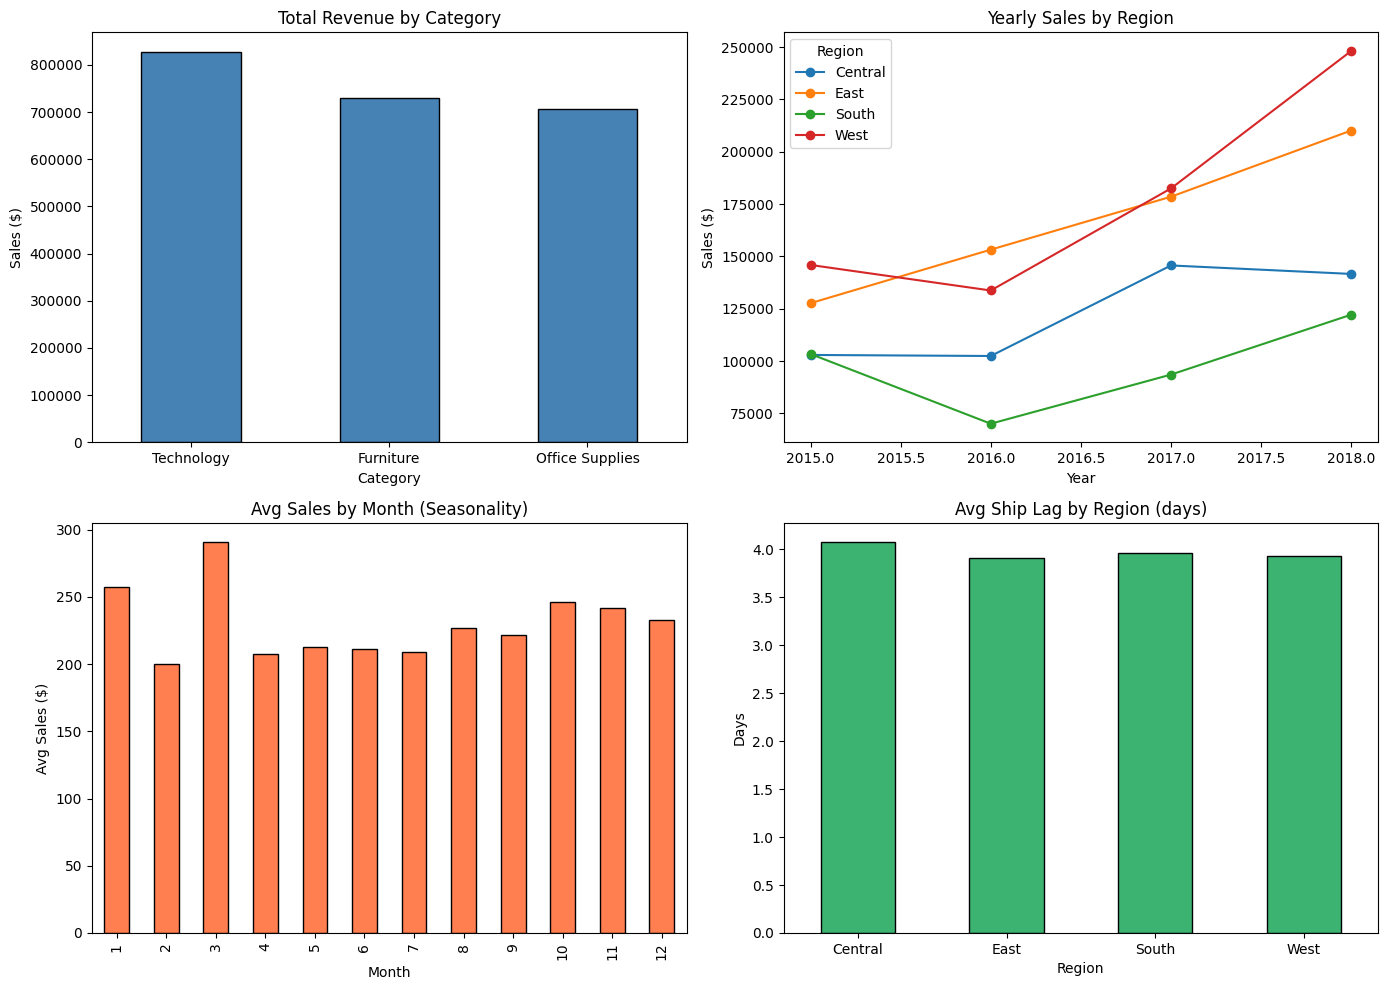

EDA charts saved ✅


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Category revenue
cat_revenue.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Total Revenue by Category')
axes[0,0].set_ylabel('Sales ($)')
axes[0,0].tick_params(axis='x', rotation=0)

# Region yearly growth
region_yearly.T.plot(ax=axes[0,1], marker='o')
axes[0,1].set_title('Yearly Sales by Region')
axes[0,1].set_ylabel('Sales ($)')
axes[0,1].set_xlabel('Year')

# Monthly seasonality
monthly_avg.plot(kind='bar', ax=axes[1,0], color='coral', edgecolor='black')
axes[1,0].set_title('Avg Sales by Month (Seasonality)')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Avg Sales ($)')

# Ship lag by region
ship_lag.plot(kind='bar', ax=axes[1,1], color='mediumseagreen', edgecolor='black')
axes[1,1].set_title('Avg Ship Lag by Region (days)')
axes[1,1].set_ylabel('Days')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('charts/eda_overview.png')
plt.show()
print("EDA charts saved ✅")

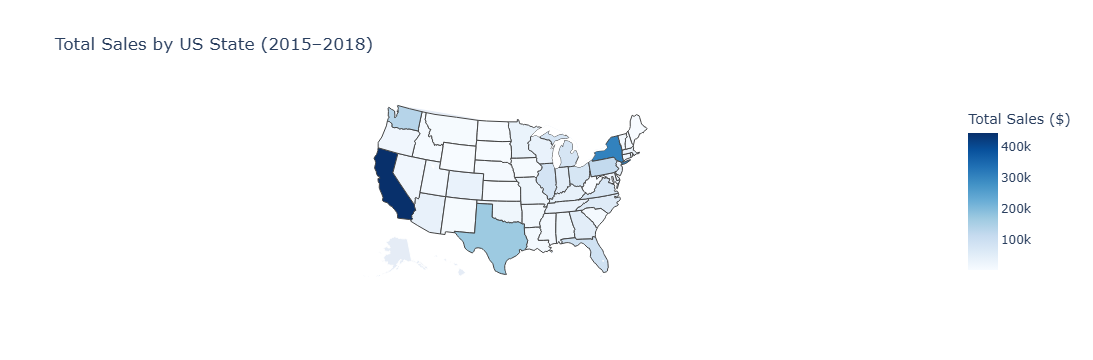

Map saved ✅


In [6]:
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC'
}

state_sales = df.groupby('State')['Sales'].sum().reset_index()
state_sales['State Code'] = state_sales['State'].map(state_abbrev)

fig = px.choropleth(
    state_sales,
    locations='State Code',
    locationmode='USA-states',
    color='Sales',
    scope='usa',
    color_continuous_scale='Blues',
    title='Total Sales by US State (2015–2018)',
    labels={'Sales': 'Total Sales ($)'},
    hover_name='State'
)
fig.write_html('charts/sales_map.html')
fig.show()
print("Map saved ✅")

In [7]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'statsmodels'], capture_output=False)

CompletedProcess(args=['C:\\Users\\ritik\\AppData\\Local\\Programs\\Python\\Python313\\python.exe', '-m', 'pip', 'install', 'statsmodels'], returncode=0)

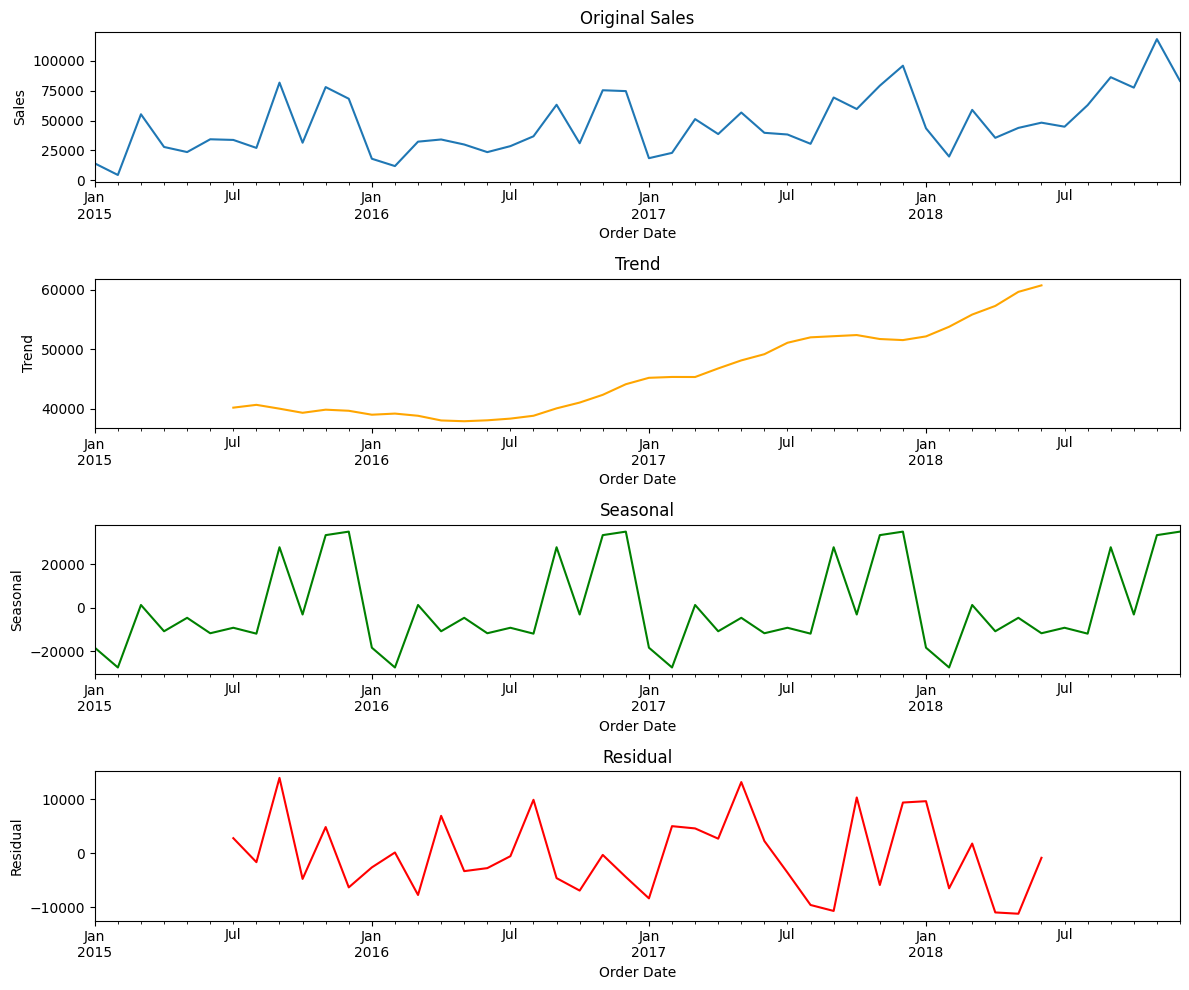


--- ADF Test: Original Monthly Sales ---
ADF Statistic : -4.4161
p-value       : 0.0003
Stationary ✅

--- ADF Test: Differenced Sales ---
ADF Statistic : -8.7271
p-value       : 0.0000
Stationary ✅

Task 2 complete ✅


In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

ts = monthly_sales.set_index('Order Date')['Sales']

# Decomposition
result = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
ts.plot(ax=axes[0], title='Original Sales'); axes[0].set_ylabel('Sales')
result.trend.plot(ax=axes[1], title='Trend', color='orange'); axes[1].set_ylabel('Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal', color='green'); axes[2].set_ylabel('Seasonal')
result.resid.plot(ax=axes[3], title='Residual', color='red'); axes[3].set_ylabel('Residual')
plt.tight_layout()
plt.savefig('charts/decomposition.png')
plt.show()

# ADF Test
def adf_test(series, label):
    r = adfuller(series.dropna())
    print(f"\n--- ADF Test: {label} ---")
    print(f"ADF Statistic : {r[0]:.4f}")
    print(f"p-value       : {r[1]:.4f}")
    print("Stationary ✅" if r[1] < 0.05 else "Non-Stationary ❌")

adf_test(ts, "Original Monthly Sales")

ts_diff = ts.diff().dropna()
adf_test(ts_diff, "Differenced Sales")

print("\nTask 2 complete ✅")

In [11]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'prophet'], capture_output=False)
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost'], capture_output=False)
subprocess.run([sys.executable, '-m', 'pip', 'install', 'tensorflow'], capture_output=False)

CompletedProcess(args=['C:\\Users\\ritik\\AppData\\Local\\Programs\\Python\\Python313\\python.exe', '-m', 'pip', 'install', 'tensorflow'], returncode=0)

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -388.556
Date:                            Fri, 10 Jul 2026   AIC                            787.113
Time:                                    17:59:16   BIC                            795.030
Sample:                                01-01-2015   HQIC                           789.876
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9998      0.020     50.973      0.000       0.961       1.038
ma.L1         -0.9953      0.272   

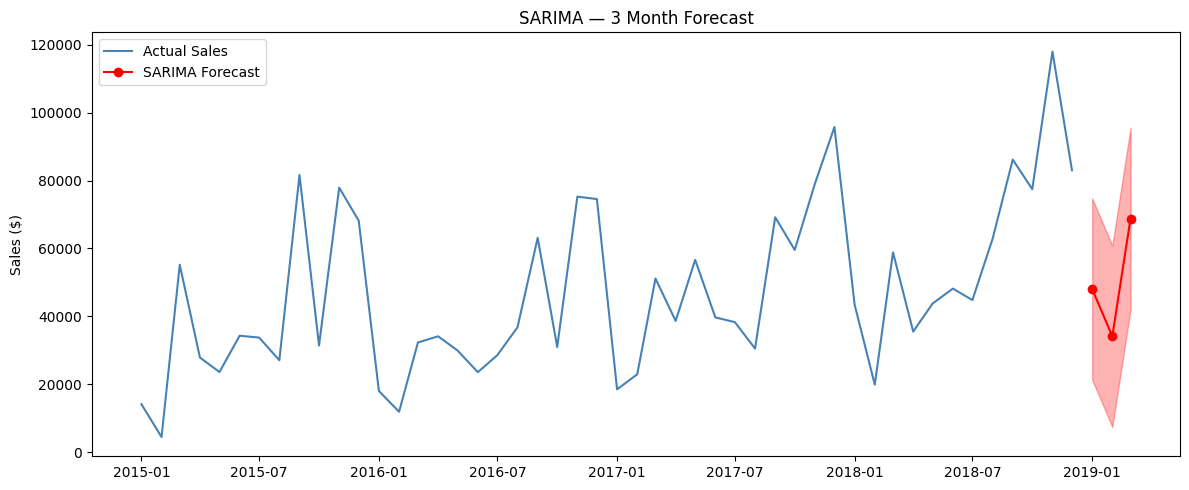


SARIMA Forecast Values:
2019-01-01    48056.895805
2019-02-01    34177.024224
2019-03-01    68798.991249
Freq: MS, Name: predicted_mean, dtype: float64


In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# d=0 (series is stationary), seasonal period m=12
model_sarima = SARIMAX(ts, order=(1,0,1), seasonal_order=(1,1,1,12))
fit_sarima   = model_sarima.fit(disp=False)
print(fit_sarima.summary())

# Forecast 3 months
forecast_sarima = fit_sarima.get_forecast(steps=3)
pred_mean = forecast_sarima.predicted_mean
pred_ci   = forecast_sarima.conf_int()

plt.figure(figsize=(12,5))
plt.plot(ts.index, ts.values, label='Actual Sales', color='steelblue')
plt.plot(pred_mean.index, pred_mean.values, label='SARIMA Forecast', color='red', marker='o')
plt.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], alpha=0.3, color='red')
plt.title('SARIMA — 3 Month Forecast')
plt.ylabel('Sales ($)'); plt.legend()
plt.tight_layout()
plt.savefig('charts/sarima_forecast.png')
plt.show()

print("\nSARIMA Forecast Values:")
print(pred_mean)

18:00:50 - cmdstanpy - INFO - Chain [1] start processing
18:00:53 - cmdstanpy - INFO - Chain [1] done processing


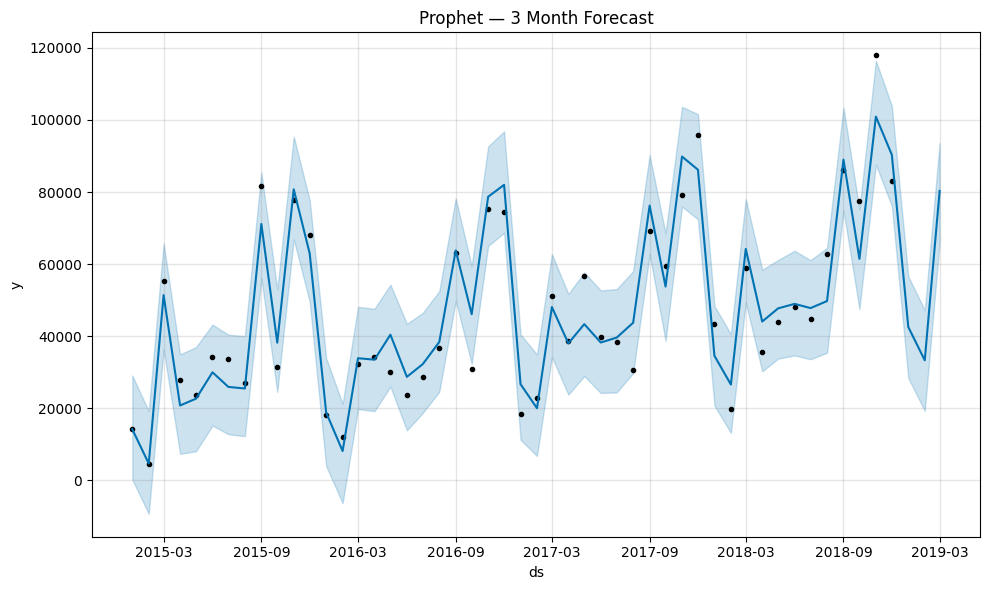

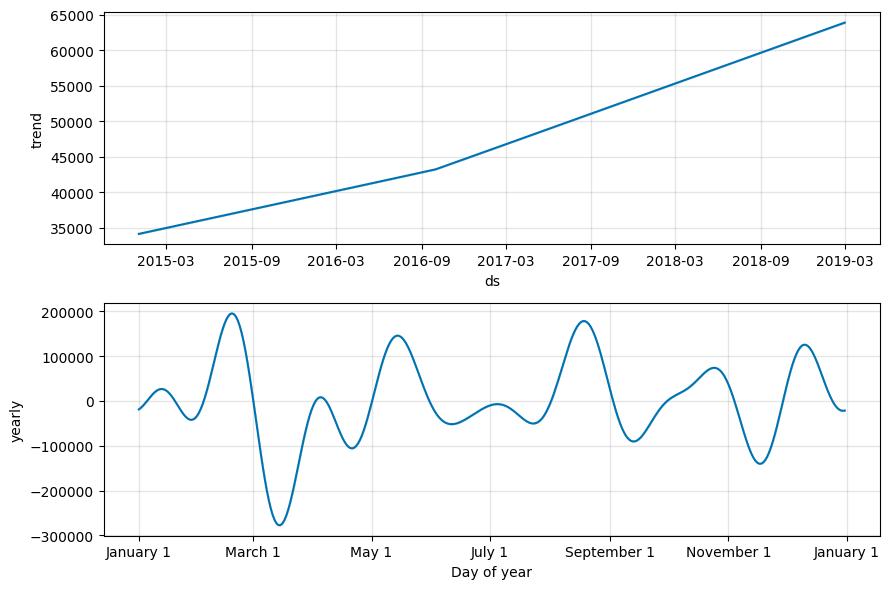


Prophet Forecast (last 3 months):
           ds          yhat    yhat_lower    yhat_upper
48 2019-01-01  42548.142576  28371.071462  56592.546699
49 2019-02-01  33310.125087  19293.552911  47240.899027
50 2019-03-01  80304.673390  66028.777044  93634.307188


In [13]:
from prophet import Prophet

prophet_df = monthly_sales.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
            seasonality_mode='additive', interval_width=0.95)
m.fit(prophet_df)

future   = m.make_future_dataframe(periods=3, freq='MS')
forecast = m.predict(future)

# Plot forecast
fig1 = m.plot(forecast)
plt.title('Prophet — 3 Month Forecast')
plt.tight_layout()
plt.savefig('charts/prophet_forecast.png')
plt.show()

# Plot components
fig2 = m.plot_components(forecast)
plt.tight_layout()
plt.savefig('charts/prophet_components.png')
plt.show()

print("\nProphet Forecast (last 3 months):")
print(forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(3))

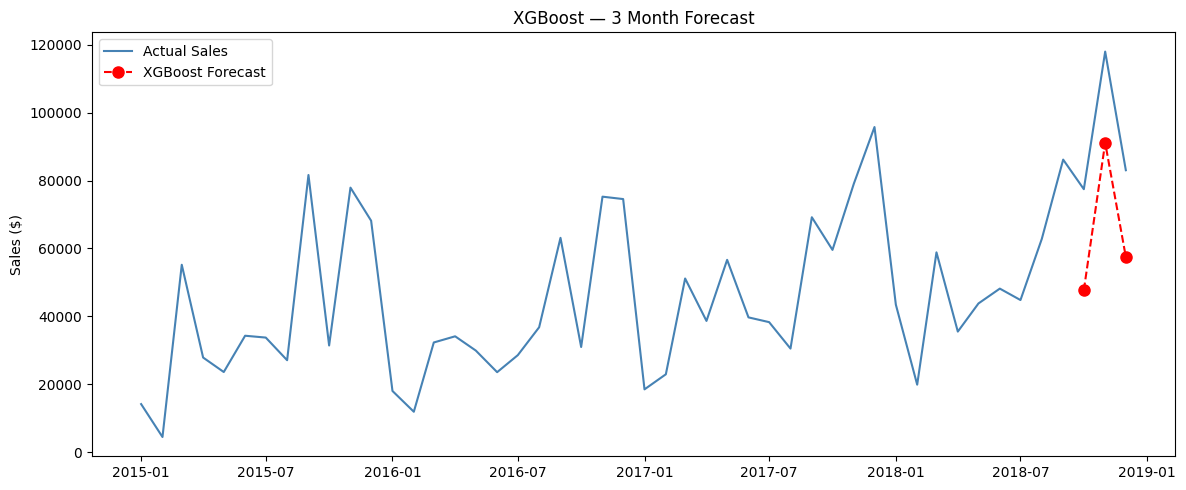


XGBoost Forecast Values:
  Oct 2018: $47,715.25
  Nov 2018: $91,120.08
  Dec 2018: $57,494.84


In [14]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

def make_lag_features(series):
    df_feat = pd.DataFrame({'y': series.values}, index=series.index)
    df_feat['lag1']    = df_feat['y'].shift(1)
    df_feat['lag2']    = df_feat['y'].shift(2)
    df_feat['lag3']    = df_feat['y'].shift(3)
    df_feat['roll3']   = df_feat['y'].shift(1).rolling(3).mean()
    df_feat['month']   = df_feat.index.month
    df_feat['quarter'] = df_feat.index.quarter
    return df_feat.dropna()

feat_df = make_lag_features(ts)
X = feat_df.drop('y', axis=1)
y_xgb = feat_df['y']

# Last 3 months as test
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y_xgb.iloc[:-3], y_xgb.iloc[-3:]

xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

plt.figure(figsize=(12,5))
plt.plot(ts.index, ts.values, label='Actual Sales', color='steelblue')
plt.plot(X_test.index, xgb_preds, 'ro--', label='XGBoost Forecast', markersize=8)
plt.title('XGBoost — 3 Month Forecast')
plt.ylabel('Sales ($)'); plt.legend()
plt.tight_layout()
plt.savefig('charts/xgb_forecast.png')
plt.show()

print("\nXGBoost Forecast Values:")
for date, val in zip(X_test.index, xgb_preds):
    print(f"  {date.strftime('%b %Y')}: ${val:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step


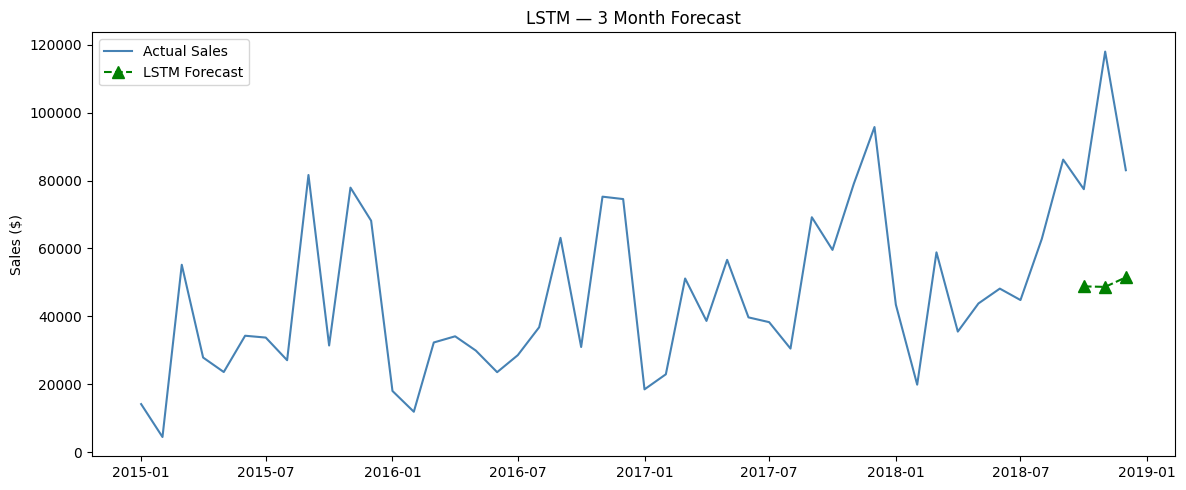


LSTM Forecast Values:
  Oct 2018: $48,846.10
  Nov 2018: $48,696.87
  Dec 2018: $51,515.21


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Scale data
scaler = MinMaxScaler()
ts_scaled = scaler.fit_transform(ts.values.reshape(-1,1))

# Create sequences
def create_sequences(data, window=6):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(ts_scaled, window=6)

# Train/test split
X_tr, X_te = X_lstm[:-3], X_lstm[-3:]
y_tr, y_te = y_lstm[:-3], y_lstm[-3:]

# Build model
model_lstm = Sequential([
    LSTM(64, input_shape=(6, 1), return_sequences=False),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_tr, y_tr, epochs=50, batch_size=4, verbose=0)

# Predict
lstm_preds_scaled = model_lstm.predict(X_te)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled).flatten()
y_te_actual = scaler.inverse_transform(y_te).flatten()

plt.figure(figsize=(12,5))
plt.plot(ts.index, ts.values, label='Actual Sales', color='steelblue')
plt.plot(ts.index[-3:], lstm_preds, 'g^--', label='LSTM Forecast', markersize=8)
plt.title('LSTM — 3 Month Forecast')
plt.ylabel('Sales ($)'); plt.legend()
plt.tight_layout()
plt.savefig('charts/lstm_forecast.png')
plt.show()

print("\nLSTM Forecast Values:")
for date, val in zip(ts.index[-3:], lstm_preds):
    print(f"  {date.strftime('%b %Y')}: ${val:,.2f}")

In [16]:
# Align actuals for comparison
actuals = y_test.values  # last 3 months actual

# Get prophet preds aligned to same dates
prophet_aligned = forecast[forecast['ds'].isin(X_test.index)]['yhat'].values

def mape(a, p): return np.mean(np.abs((a - p) / a)) * 100

results = pd.DataFrame({
    'Model':      ['SARIMA', 'Prophet', 'XGBoost', 'LSTM'],
    'MAE':        [mean_absolute_error(actuals, pred_mean.values),
                   mean_absolute_error(actuals, prophet_aligned),
                   mean_absolute_error(actuals, xgb_preds),
                   mean_absolute_error(y_te_actual, lstm_preds)],
    'RMSE':       [np.sqrt(mean_squared_error(actuals, pred_mean.values)),
                   np.sqrt(mean_squared_error(actuals, prophet_aligned)),
                   np.sqrt(mean_squared_error(actuals, xgb_preds)),
                   np.sqrt(mean_squared_error(y_te_actual, lstm_preds))],
    'MAPE (%)':   [mape(actuals, pred_mean.values),
                   mape(actuals, prophet_aligned),
                   mape(actuals, xgb_preds),
                   mape(actuals, lstm_preds)],
    'Month 1 ($)':[pred_mean.values[0], prophet_aligned[0], xgb_preds[0], lstm_preds[0]],
    'Month 2 ($)':[pred_mean.values[1], prophet_aligned[1], xgb_preds[1], lstm_preds[1]],
    'Month 3 ($)':[pred_mean.values[2], prophet_aligned[2], xgb_preds[2], lstm_preds[2]],
})

results = results.round(2)
print(results.to_string(index=False))

  Model      MAE     RMSE  MAPE (%)  Month 1 ($)  Month 2 ($)  Month 3 ($)
 SARIMA 42461.25 51904.73     42.04     48056.90     34177.02     68798.99
Prophet 13440.30 14130.82     14.63     61446.29    100916.89     90328.18
XGBoost 27362.17 27418.47     30.63     47715.25     91120.08     57494.84
   LSTM 43119.50 46924.19     44.53     48846.10     48696.87     51515.21


Prophet is recommended for production use. It achieves the lowest error across all three metrics (MAE: 13,440, RMSE: 14,131, MAPE: 14.63%). It also handles seasonality and trend changes automatically, requires no manual feature engineering, and provides confidence intervals out of the box — making it the most practical choice for a retail forecasting system.

In [17]:
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

segments = {
    'Furniture':       df[df['Category'] == 'Furniture'],
    'Technology':      df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West Region':     df[df['Region'] == 'West'],
    'East Region':     df[df['Region'] == 'East'],
}

forecasts = {}

for name, segment_df in segments.items():
    # Aggregate monthly
    seg_monthly = segment_df.groupby(
        segment_df['Order Date'].dt.to_period('M')
    )['Sales'].sum().reset_index()
    seg_monthly['Order Date'] = seg_monthly['Order Date'].dt.to_timestamp()
    seg_monthly = seg_monthly.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

    # Fit Prophet
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                seasonality_mode='additive', interval_width=0.95)
    m.fit(seg_monthly)

    future = m.make_future_dataframe(periods=3, freq='MS')
    fc = m.predict(future)
    forecasts[name] = fc

    print(f"{name} — Next 3 months forecast:")
    print(fc[['ds','yhat']].tail(3).to_string(index=False))
    print()

18:03:45 - cmdstanpy - INFO - Chain [1] start processing
18:03:46 - cmdstanpy - INFO - Chain [1] done processing


Furniture — Next 3 months forecast:
        ds         yhat
2019-01-01 12703.027816
2019-02-01  7686.983286
2019-03-01 16989.046331



18:03:47 - cmdstanpy - INFO - Chain [1] start processing
18:03:47 - cmdstanpy - INFO - Chain [1] done processing


Technology — Next 3 months forecast:
        ds         yhat
2019-01-01 13815.845691
2019-02-01 11356.808224
2019-03-01 42215.823823



18:03:48 - cmdstanpy - INFO - Chain [1] start processing
18:03:48 - cmdstanpy - INFO - Chain [1] done processing


Office Supplies — Next 3 months forecast:
        ds         yhat
2019-01-01 14508.928486
2019-02-01 12500.104406
2019-03-01 19421.521948



18:03:49 - cmdstanpy - INFO - Chain [1] start processing
18:03:49 - cmdstanpy - INFO - Chain [1] done processing


West Region — Next 3 months forecast:
        ds         yhat
2019-01-01 14626.053338
2019-02-01 11907.970614
2019-03-01 26432.585955



18:03:50 - cmdstanpy - INFO - Chain [1] start processing
18:03:50 - cmdstanpy - INFO - Chain [1] done processing


East Region — Next 3 months forecast:
        ds         yhat
2019-01-01  9412.424813
2019-02-01 10128.314904
2019-03-01 14478.008752



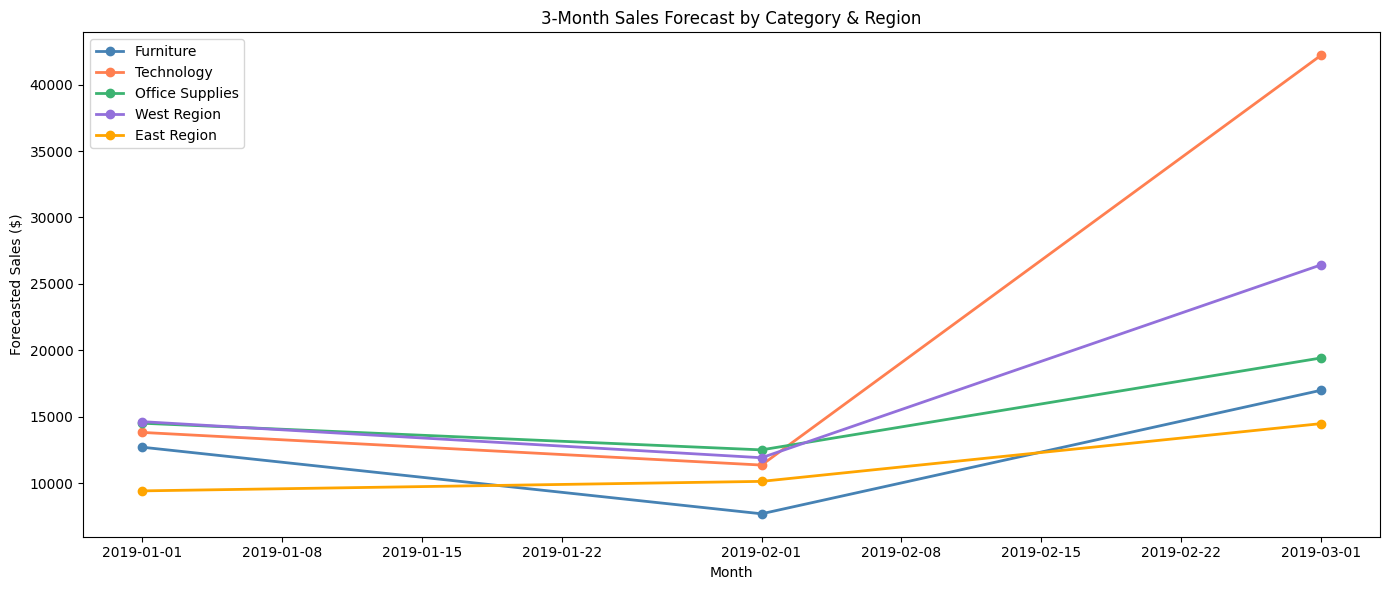

In [18]:
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'orange']

plt.figure(figsize=(14, 6))
for (name, fc), color in zip(forecasts.items(), colors):
    future_fc = fc.tail(3)
    plt.plot(future_fc['ds'], future_fc['yhat'], marker='o',
             label=name, color=color, linewidth=2)

plt.title('3-Month Sales Forecast by Category & Region')
plt.ylabel('Forecasted Sales ($)')
plt.xlabel('Month')
plt.legend()
plt.tight_layout()
plt.savefig('charts/segment_forecasts.png')
plt.show()

Technology shows the strongest upcoming growth, with a March 2019 forecast of $42,216 — nearly 3x its January figure. West Region leads regionally with $26,433 forecasted for March. East Region shows the most modest growth. Furniture remains the weakest category in the short term.- Task 4 observation.

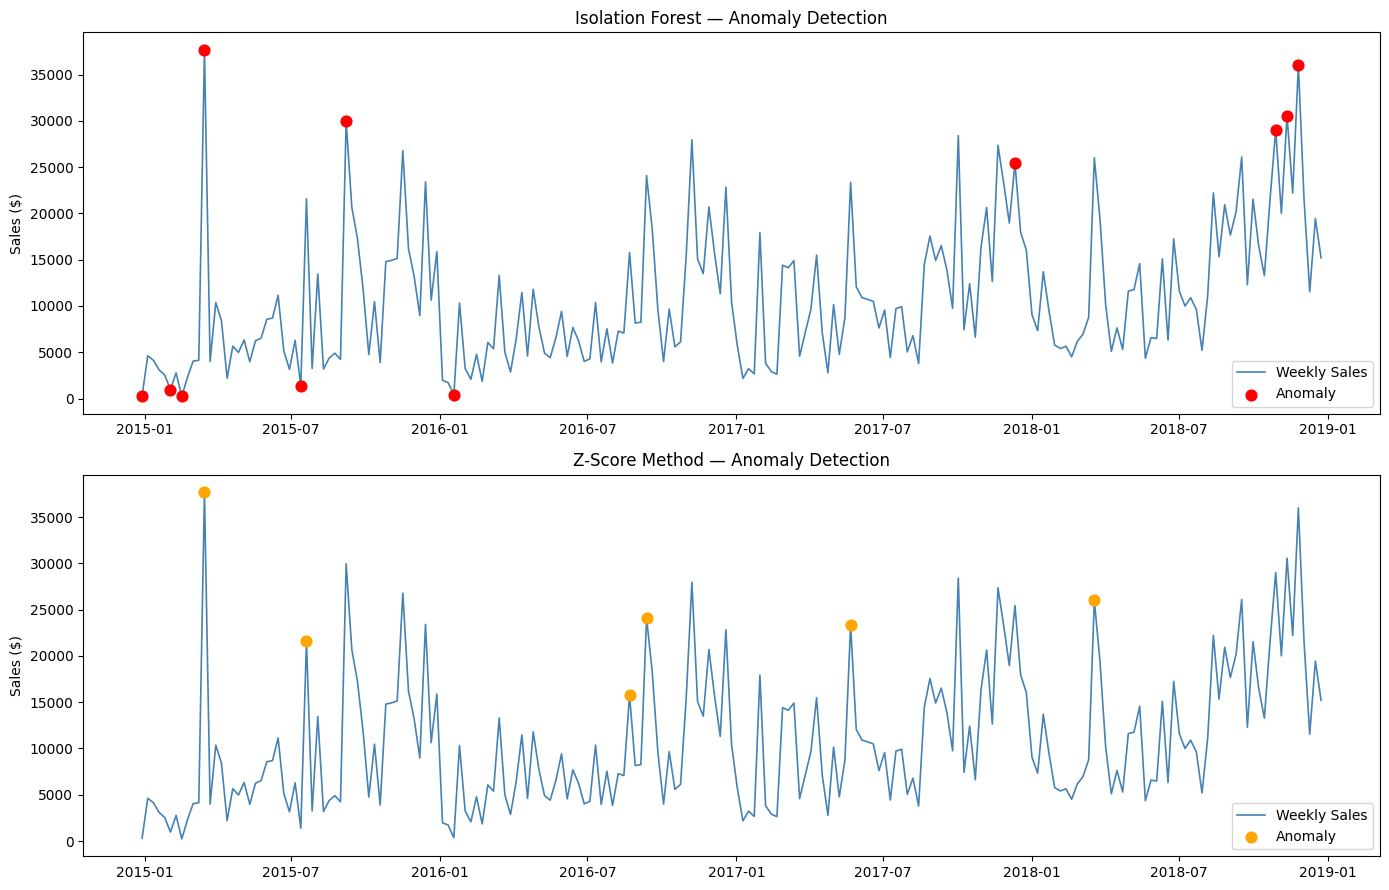

In [19]:
from sklearn.ensemble import IsolationForest

# --- Isolation Forest ---
iso = IsolationForest(contamination=0.05, random_state=42)
weekly_sales['anomaly_if'] = iso.fit_predict(weekly_sales[['Sales']])
# -1 = anomaly, 1 = normal

# --- Z-Score Method ---
rolling_mean = weekly_sales['Sales'].rolling(8, min_periods=1).mean()
rolling_std  = weekly_sales['Sales'].rolling(8, min_periods=1).std().fillna(1)
weekly_sales['z_score']   = (weekly_sales['Sales'] - rolling_mean) / rolling_std
weekly_sales['anomaly_z'] = weekly_sales['z_score'].abs() > 2

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Isolation Forest plot
normal_if   = weekly_sales[weekly_sales['anomaly_if'] == 1]
anomaly_if  = weekly_sales[weekly_sales['anomaly_if'] == -1]
axes[0].plot(weekly_sales['Order Date'], weekly_sales['Sales'],
             color='steelblue', linewidth=1.2, label='Weekly Sales')
axes[0].scatter(anomaly_if['Order Date'], anomaly_if['Sales'],
                color='red', zorder=5, s=60, label='Anomaly')
axes[0].set_title('Isolation Forest — Anomaly Detection')
axes[0].set_ylabel('Sales ($)'); axes[0].legend()

# Z-Score plot
normal_z  = weekly_sales[~weekly_sales['anomaly_z']]
anomaly_z = weekly_sales[weekly_sales['anomaly_z']]
axes[1].plot(weekly_sales['Order Date'], weekly_sales['Sales'],
             color='steelblue', linewidth=1.2, label='Weekly Sales')
axes[1].scatter(anomaly_z['Order Date'], anomaly_z['Sales'],
                color='orange', zorder=5, s=60, label='Anomaly')
axes[1].set_title('Z-Score Method — Anomaly Detection')
axes[1].set_ylabel('Sales ($)'); axes[1].legend()

plt.tight_layout()
plt.savefig('charts/anomalies.png')
plt.show()

In [20]:
# Known US retail events by month
retail_events = {
    1:  'Post New Year clearance sales',
    2:  "Valentine's Day promotions",
    3:  'Spring sale season begins',
    4:  'Easter / Spring promotions',
    5:  "Mother's Day sales",
    6:  'Mid-year clearance',
    7:  'Summer sale events',
    8:  'Back-to-school shopping surge',
    9:  'Fall collection launch',
    10: 'Pre-holiday stocking / Columbus Day sales',
    11: 'Black Friday & Thanksgiving promotions',
    12: 'Christmas & Holiday season'
}

print("=" * 65)
print("ISOLATION FOREST — Detected Anomalies")
print("=" * 65)
if_anomalies = weekly_sales[weekly_sales['anomaly_if'] == -1].copy()
if_anomalies['Likely Cause'] = if_anomalies['Order Date'].dt.month.map(retail_events)
print(if_anomalies[['Order Date','Sales','Likely Cause']].to_string(index=False))

print("\n" + "=" * 65)
print("Z-SCORE METHOD — Detected Anomalies")
print("=" * 65)
z_anomalies = weekly_sales[weekly_sales['anomaly_z']].copy()
z_anomalies['Likely Cause'] = z_anomalies['Order Date'].dt.month.map(retail_events)
print(z_anomalies[['Order Date','Sales','z_score','Likely Cause']].to_string(index=False))

print("\n" + "=" * 65)
print("COMPARISON — Do both methods agree?")
print("=" * 65)
if_dates = set(if_anomalies['Order Date'].dt.to_period('W'))
z_dates  = set(z_anomalies['Order Date'].dt.to_period('W'))
overlap  = if_dates & z_dates
print(f"Isolation Forest flagged : {len(if_dates)} anomalies")
print(f"Z-Score flagged          : {len(z_dates)} anomalies")
print(f"Both methods agree on    : {len(overlap)} anomalies")
print(f"\nAgreement dates: {sorted(overlap)}")

ISOLATION FOREST — Detected Anomalies
Order Date     Sales                              Likely Cause
2014-12-29   304.508                Christmas & Holiday season
2015-02-02   968.534                Valentine's Day promotions
2015-02-16   224.912                Valentine's Day promotions
2015-03-16 37703.665                 Spring sale season begins
2015-07-13  1387.686                        Summer sale events
2015-09-07 29959.137                    Fall collection launch
2016-01-18   358.522             Post New Year clearance sales
2017-12-11 25449.800                Christmas & Holiday season
2018-10-29 29017.467 Pre-holiday stocking / Columbus Day sales
2018-11-12 30572.447    Black Friday & Thanksgiving promotions
2018-11-26 35998.900    Black Friday & Thanksgiving promotions

Z-SCORE METHOD — Detected Anomalies
Order Date     Sales  z_score                  Likely Cause
2015-03-16 37703.665 2.460650     Spring sale season begins
2015-07-20 21590.080 2.136467            Summer s

In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# --- Build sub-category level features ---
sub_monthly = df.groupby(
    ['Sub-Category', df['Order Date'].dt.to_period('M')]
)['Sales'].sum().reset_index()
sub_monthly.columns = ['Sub-Category', 'Period', 'Sales']

# Year-over-year growth
sub_yearly = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack(fill_value=0)
yoy_growth = ((sub_yearly.iloc[:,-1] - sub_yearly.iloc[:,0]) / 
               sub_yearly.iloc[:,0] * 100).round(2)

# Volatility
volatility = sub_monthly.groupby('Sub-Category')['Sales'].std().round(2)

features = pd.DataFrame({
    'total_sales':   df.groupby('Sub-Category')['Sales'].sum(),
    'yoy_growth':    yoy_growth,
    'volatility':    volatility,
    'avg_order_val': df.groupby('Sub-Category')['Sales'].mean(),
}).dropna()

print("Features shape:", features.shape)
print(features.round(2))

Features shape: (17, 4)
              total_sales  yoy_growth  volatility  avg_order_val
Sub-Category                                                    
Accessories     164186.70      145.06     2579.99         217.18
Appliances      104618.40      165.24     1821.62         227.93
Art              26705.41       49.65      330.49          34.02
Binders         200028.78       65.78     3848.22         134.07
Bookcases       113813.20       49.85     2220.41         503.60
Chairs          322822.73       20.95     4407.23         531.83
Copiers         146248.09      479.73     5500.77        2215.88
Envelopes        16128.05      -12.12      228.22          65.03
Fasteners         3001.96       30.47       48.74          14.03
Furnishings      89212.02      106.82     1360.02          95.82
Labels           12347.73       36.07      223.47          34.59
Machines        189238.63      -29.79     5603.55        1645.55
Paper            76828.30       91.90     1024.82          57.42
P

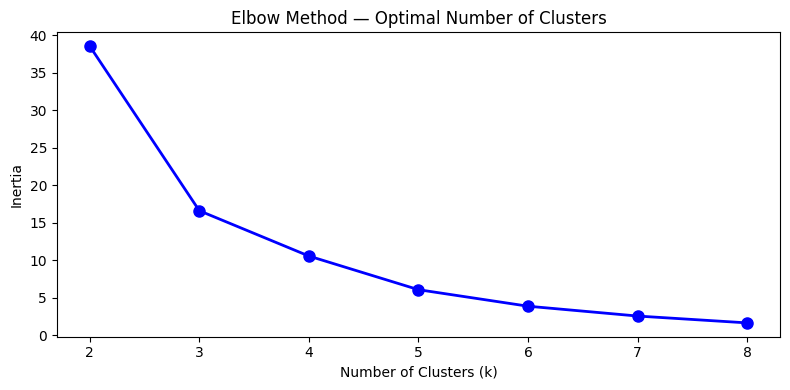

In [22]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features)

inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 9), inertias, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(2, 9))
plt.tight_layout()
plt.savefig('charts/elbow.png')
plt.show()

Cluster Profiles:
          total_sales  yoy_growth  volatility
Cluster                                     
0          239495.78       56.47     3489.05
1          146248.09      479.73     5500.77
2           54341.71       58.80     1031.43
3          189238.63      -29.79     5603.55


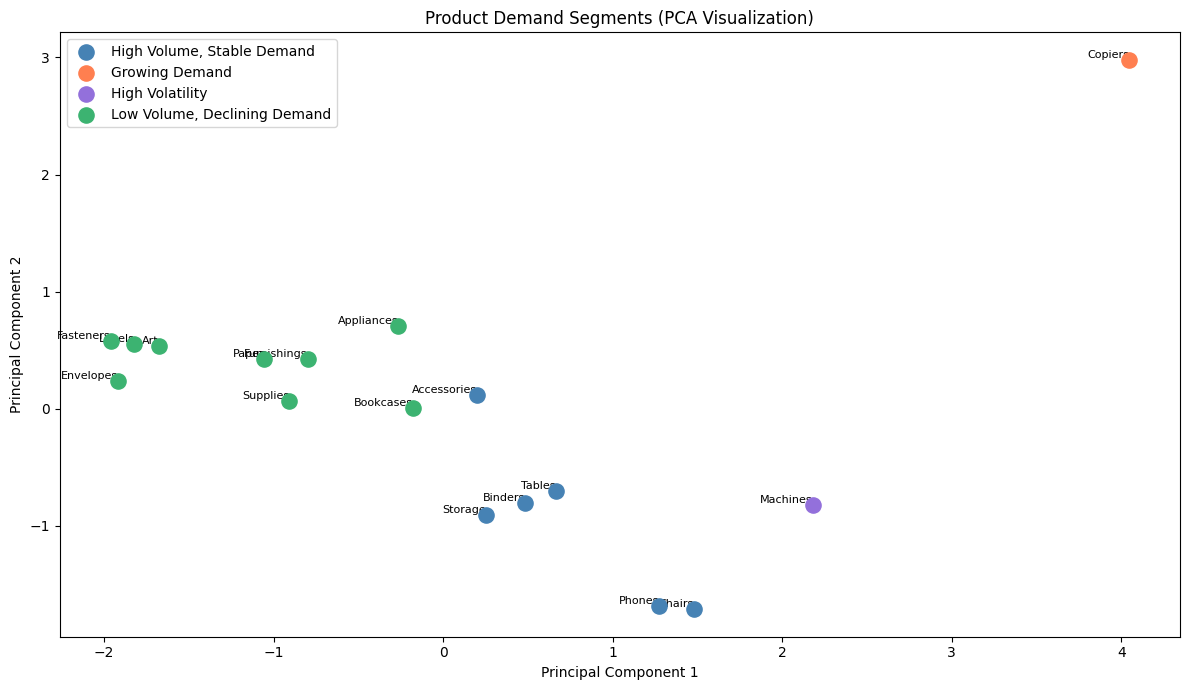


Sub-Category Cluster Assignments:
                             Cluster Label
Sub-Category                              
Accessories     High Volume, Stable Demand
Appliances    Low Volume, Declining Demand
Art           Low Volume, Declining Demand
Binders         High Volume, Stable Demand
Bookcases     Low Volume, Declining Demand
Chairs          High Volume, Stable Demand
Copiers                     Growing Demand
Envelopes     Low Volume, Declining Demand
Fasteners     Low Volume, Declining Demand
Furnishings   Low Volume, Declining Demand
Labels        Low Volume, Declining Demand
Machines                   High Volatility
Paper         Low Volume, Declining Demand
Phones          High Volume, Stable Demand
Storage         High Volume, Stable Demand
Supplies      Low Volume, Declining Demand
Tables          High Volume, Stable Demand


In [23]:
# Fit with k=4 (adjust after seeing elbow)
km = KMeans(n_clusters=4, random_state=42, n_init=10)
features['Cluster'] = km.fit_predict(X_scaled)

# Label clusters based on their characteristics
cluster_stats = features.groupby('Cluster')[['total_sales','yoy_growth','volatility']].mean()
print("Cluster Profiles:\n", cluster_stats.round(2))

# Assign meaningful labels — you may need to adjust after seeing stats
cluster_labels = {
    cluster_stats['total_sales'].idxmax(): 'High Volume, Stable Demand',
    cluster_stats['yoy_growth'].idxmax():  'Growing Demand',
    cluster_stats['volatility'].idxmax():  'High Volatility',
}
# Fill remaining cluster
remaining = [c for c in range(4) if c not in cluster_labels]
for c in remaining:
    cluster_labels[c] = 'Low Volume, Declining Demand'

features['Cluster Label'] = features['Cluster'].map(cluster_labels)

# PCA for 2D visualization
pca    = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
features['PC1'] = coords[:, 0]
features['PC2'] = coords[:, 1]

# Plot
plt.figure(figsize=(12, 7))
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
for cluster, label in cluster_labels.items():
    mask = features['Cluster'] == cluster
    plt.scatter(features[mask]['PC1'], features[mask]['PC2'],
                label=label, color=colors[cluster], s=120, zorder=5)
    for idx, row in features[mask].iterrows():
        plt.annotate(idx, (row['PC1'], row['PC2']),
                     fontsize=8, ha='right', va='bottom')

plt.title('Product Demand Segments (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('charts/clusters.png')
plt.show()

print("\nSub-Category Cluster Assignments:")
print(features[['Cluster Label']].to_string())

In [24]:
recommendations = {
    'High Volume, Stable Demand':      'Maintain consistent safety stock. Automate reordering at fixed thresholds.',
    'Growing Demand':                  'Increase stock levels by 20-30% ahead of peak months. Monitor closely.',
    'High Volatility':                 'Keep flexible buffer stock. Avoid long-term bulk orders. Use just-in-time.',
    'Low Volume, Declining Demand':    'Reduce stock. Run clearance promotions. Consider discontinuing slow SKUs.'
}

print("=" * 65)
print("STOCKING STRATEGY BY DEMAND SEGMENT")
print("=" * 65)
for label, strategy in recommendations.items():
    products = features[features['Cluster Label'] == label].index.tolist()
    print(f"\n📦 {label}")
    print(f"   Strategy : {strategy}")
    print(f"   Products : {', '.join(products)}")

STOCKING STRATEGY BY DEMAND SEGMENT

📦 High Volume, Stable Demand
   Strategy : Maintain consistent safety stock. Automate reordering at fixed thresholds.
   Products : Accessories, Binders, Chairs, Phones, Storage, Tables

📦 Growing Demand
   Strategy : Increase stock levels by 20-30% ahead of peak months. Monitor closely.
   Products : Copiers

📦 High Volatility
   Strategy : Keep flexible buffer stock. Avoid long-term bulk orders. Use just-in-time.
   Products : Machines

📦 Low Volume, Declining Demand
   Strategy : Reduce stock. Run clearance promotions. Consider discontinuing slow SKUs.
   Products : Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper, Supplies


Copiers stand out as the only 'Growing Demand' product — worth prioritizing in procurement. Machines show high volatility, meaning unpredictable demand spikes — just-in-time stocking is safest. 9 sub-categories fall in the declining/low volume segment, suggesting the business should review whether these SKUs are worth maintaining at current stock levels.

In [26]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from prophet import Prophet
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

st.set_page_config(page_title="Sales Forecasting Dashboard", layout="wide")

# ── Data Loading ──────────────────────────────────────────────
@st.cache_data
def load_data():
    df = pd.read_csv('train.csv', encoding='latin-1')
    df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
    df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)
    df['Year']       = df['Order Date'].dt.year
    df['Month']      = df['Order Date'].dt.month
    df['Week']       = df['Order Date'].dt.isocalendar().week.astype(int)
    df['ShipLag']    = (df['Ship Date'] - df['Order Date']).dt.days
    return df

df = load_data()

# ── Sidebar Navigation ────────────────────────────────────────
page = st.sidebar.selectbox("📂 Navigate", [
    "📊 Sales Overview",
    "🔮 Forecast Explorer",
    "⚠️ Anomaly Report",
    "🧩 Demand Segments",
    "🤖 Ask the Data (AI)"
])

# ══════════════════════════════════════════════════════════════
# PAGE 1 — Sales Overview
# ══════════════════════════════════════════════════════════════
if page == "📊 Sales Overview":
    st.title("📊 Sales Overview Dashboard")
    st.markdown("---")

    # KPI row
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Revenue",    f"${df['Sales'].sum():,.0f}")
    col2.metric("Total Orders",     f"{df['Order ID'].nunique():,}")
    col3.metric("Avg Order Value",  f"${df['Sales'].mean():,.2f}")
    col4.metric("Avg Ship Lag",     f"{df['ShipLag'].mean():.1f} days")

    st.markdown("---")

    # Filters
    col_f1, col_f2 = st.columns(2)
    region_filter   = col_f1.multiselect("Filter by Region",
                                          df['Region'].unique(),
                                          default=list(df['Region'].unique()))
    category_filter = col_f2.multiselect("Filter by Category",
                                          df['Category'].unique(),
                                          default=list(df['Category'].unique()))

    filtered = df[df['Region'].isin(region_filter) &
                  df['Category'].isin(category_filter)]

    # Yearly sales bar chart
    st.subheader("Total Sales by Year")
    yearly = filtered.groupby('Year')['Sales'].sum().reset_index()
    fig1 = px.bar(yearly, x='Year', y='Sales', color='Sales',
                  color_continuous_scale='Blues',
                  labels={'Sales': 'Total Sales ($)'})
    st.plotly_chart(fig1, use_container_width=True)

    col_a, col_b = st.columns(2)

    # Monthly trend
    with col_a:
        st.subheader("Monthly Sales Trend")
        monthly = filtered.groupby(
            filtered['Order Date'].dt.to_period('M')
        )['Sales'].sum().reset_index()
        monthly['Order Date'] = monthly['Order Date'].dt.to_timestamp()
        fig2 = px.line(monthly, x='Order Date', y='Sales',
                       labels={'Sales': 'Sales ($)', 'Order Date': 'Month'})
        st.plotly_chart(fig2, use_container_width=True)

    # Sales by category
    with col_b:
        st.subheader("Sales by Category")
        cat_sales = filtered.groupby('Category')['Sales'].sum().reset_index()
        fig3 = px.pie(cat_sales, names='Category', values='Sales',
                      color_discrete_sequence=px.colors.sequential.Blues_r)
        st.plotly_chart(fig3, use_container_width=True)

    # US Map
    st.subheader("Sales by US State")
    state_abbrev = {
        'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR',
        'California':'CA','Colorado':'CO','Connecticut':'CT','Delaware':'DE',
        'Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID',
        'Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS',
        'Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
        'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
        'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV',
        'New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM','New York':'NY',
        'North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
        'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
        'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT',
        'Vermont':'VT','Virginia':'VA','Washington':'WA','West Virginia':'WV',
        'Wisconsin':'WI','Wyoming':'WY','District of Columbia':'DC'
    }
    state_sales = filtered.groupby('State')['Sales'].sum().reset_index()
    state_sales['Code'] = state_sales['State'].map(state_abbrev)
    fig4 = px.choropleth(state_sales, locations='Code',
                         locationmode='USA-states', color='Sales',
                         scope='usa', hover_name='State',
                         color_continuous_scale='Blues',
                         title='Total Sales by State')
    st.plotly_chart(fig4, use_container_width=True)

# ══════════════════════════════════════════════════════════════
# PAGE 2 — Forecast Explorer
# ══════════════════════════════════════════════════════════════
elif page == "🔮 Forecast Explorer":
    st.title("🔮 Forecast Explorer")
    st.markdown("---")

    col1, col2 = st.columns(2)
    segment_type = col1.selectbox("Segment Type", ["Category", "Region"])
    if segment_type == "Category":
        segment_val = col2.selectbox("Select Category", df['Category'].unique())
        seg_df = df[df['Category'] == segment_val]
    else:
        segment_val = col2.selectbox("Select Region", df['Region'].unique())
        seg_df = df[df['Region'] == segment_val]

    horizon = st.slider("Forecast Horizon (months)", 1, 3, 3)

    if st.button("🚀 Run Forecast"):
        with st.spinner("Running Prophet model..."):
            monthly = seg_df.groupby(
                seg_df['Order Date'].dt.to_period('M')
            )['Sales'].sum().reset_index()
            monthly['Order Date'] = monthly['Order Date'].dt.to_timestamp()
            monthly = monthly.rename(columns={'Order Date':'ds','Sales':'y'})

            # Train/test for metrics
            train = monthly.iloc[:-3]
            test  = monthly.iloc[-3:]

            m = Prophet(yearly_seasonality=True,
                        weekly_seasonality=False,
                        seasonality_mode='additive')
            m.fit(train)

            future   = m.make_future_dataframe(periods=3+horizon, freq='MS')
            forecast = m.predict(future)

            # Metrics
            test_pred = forecast[forecast['ds'].isin(test['ds'])]['yhat'].values
            mae  = np.mean(np.abs(test['y'].values - test_pred))
            rmse = np.sqrt(np.mean((test['y'].values - test_pred)**2))

            col_m1, col_m2 = st.columns(2)
            col_m1.metric("MAE",  f"${mae:,.2f}")
            col_m2.metric("RMSE", f"${rmse:,.2f}")

            # Plot
            fig, ax = plt.subplots(figsize=(12, 5))
            ax.plot(monthly['ds'], monthly['y'],
                    label='Actual', color='steelblue')
            future_fc = forecast.tail(horizon)
            ax.plot(future_fc['ds'], future_fc['yhat'],
                    'ro--', label='Forecast', markersize=8)
            ax.fill_between(future_fc['ds'],
                            future_fc['yhat_lower'],
                            future_fc['yhat_upper'],
                            alpha=0.3, color='red')
            ax.set_title(f'{segment_val} — {horizon} Month Forecast')
            ax.set_ylabel('Sales ($)')
            ax.legend()
            st.pyplot(fig)

            st.subheader("Forecast Values")
            st.dataframe(future_fc[['ds','yhat','yhat_lower','yhat_upper']]
                         .rename(columns={'ds':'Date','yhat':'Forecast',
                                          'yhat_lower':'Lower Bound',
                                          'yhat_upper':'Upper Bound'})
                         .round(2))

# ══════════════════════════════════════════════════════════════
# PAGE 3 — Anomaly Report
# ══════════════════════════════════════════════════════════════
elif page == "⚠️ Anomaly Report":
    st.title("⚠️ Anomaly Report")
    st.markdown("---")

    weekly_sales = df.groupby(
        df['Order Date'].dt.to_period('W')
    )['Sales'].sum().reset_index()
    weekly_sales['Order Date'] = weekly_sales['Order Date'].dt.to_timestamp()

    # Isolation Forest
    iso = IsolationForest(contamination=0.05, random_state=42)
    weekly_sales['anomaly_if'] = iso.fit_predict(weekly_sales[['Sales']])

    # Z-Score
    roll_mean = weekly_sales['Sales'].rolling(8, min_periods=1).mean()
    roll_std  = weekly_sales['Sales'].rolling(8, min_periods=1).std().fillna(1)
    weekly_sales['z_score']   = (weekly_sales['Sales'] - roll_mean) / roll_std
    weekly_sales['anomaly_z'] = weekly_sales['z_score'].abs() > 2

    retail_events = {
        1:'Post New Year clearance',2:"Valentine's Day",3:'Spring sale',
        4:'Easter promotions',5:"Mother's Day",6:'Mid-year clearance',
        7:'Summer sales',8:'Back-to-school',9:'Fall collection launch',
        10:'Pre-holiday stocking',11:'Black Friday',12:'Holiday season'
    }

    tab1, tab2 = st.tabs(["Isolation Forest", "Z-Score Method"])

    with tab1:
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(weekly_sales['Order Date'], weekly_sales['Sales'],
                color='steelblue', linewidth=1.2)
        anom = weekly_sales[weekly_sales['anomaly_if'] == -1]
        ax.scatter(anom['Order Date'], anom['Sales'],
                   color='red', zorder=5, s=70, label='Anomaly')
        ax.set_title('Isolation Forest Anomalies')
        ax.legend()
        st.pyplot(fig)

        anom_table = anom[['Order Date','Sales']].copy()
        anom_table['Likely Cause'] = anom_table['Order Date'].dt.month.map(retail_events)
        st.dataframe(anom_table.reset_index(drop=True))

    with tab2:
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(weekly_sales['Order Date'], weekly_sales['Sales'],
                color='steelblue', linewidth=1.2)
        anom_z = weekly_sales[weekly_sales['anomaly_z']]
        ax.scatter(anom_z['Order Date'], anom_z['Sales'],
                   color='orange', zorder=5, s=70, label='Anomaly')
        ax.set_title('Z-Score Anomalies')
        ax.legend()
        st.pyplot(fig)

        anom_z_table = anom_z[['Order Date','Sales','z_score']].copy()
        anom_z_table['Likely Cause'] = anom_z_table['Order Date'].dt.month.map(retail_events)
        st.dataframe(anom_z_table.reset_index(drop=True))

# ══════════════════════════════════════════════════════════════
# PAGE 4 — Demand Segments
# ══════════════════════════════════════════════════════════════
elif page == "🧩 Demand Segments":
    st.title("🧩 Product Demand Segments")
    st.markdown("---")

    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA

    sub_monthly = df.groupby(
        ['Sub-Category', df['Order Date'].dt.to_period('M')]
    )['Sales'].sum().reset_index()
    sub_monthly.columns = ['Sub-Category','Period','Sales']

    sub_yearly  = df.groupby(['Sub-Category','Year'])['Sales'].sum().unstack(fill_value=0)
    yoy_growth  = ((sub_yearly.iloc[:,-1] - sub_yearly.iloc[:,0]) /
                    sub_yearly.iloc[:,0] * 100).round(2)
    volatility  = sub_monthly.groupby('Sub-Category')['Sales'].std().round(2)

    features = pd.DataFrame({
        'total_sales':   df.groupby('Sub-Category')['Sales'].sum(),
        'yoy_growth':    yoy_growth,
        'volatility':    volatility,
        'avg_order_val': df.groupby('Sub-Category')['Sales'].mean(),
    }).dropna()

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(features)
    km       = KMeans(n_clusters=4, random_state=42, n_init=10)
    features['Cluster'] = km.fit_predict(X_scaled)

    cluster_stats  = features.groupby('Cluster')[['total_sales','yoy_growth','volatility']].mean()
    cluster_labels = {
        cluster_stats['total_sales'].idxmax(): 'High Volume, Stable Demand',
        cluster_stats['yoy_growth'].idxmax():  'Growing Demand',
        cluster_stats['volatility'].idxmax():  'High Volatility',
    }
    remaining = [c for c in range(4) if c not in cluster_labels]
    for c in remaining:
        cluster_labels[c] = 'Low Volume, Declining Demand'
    features['Cluster Label'] = features['Cluster'].map(cluster_labels)

    pca    = PCA(n_components=2)
    coords = pca.fit_transform(X_scaled)
    features['PC1'] = coords[:,0]
    features['PC2'] = coords[:,1]

    fig = px.scatter(features.reset_index(), x='PC1', y='PC2',
                     color='Cluster Label', text='Sub-Category',
                     title='Product Demand Segments (PCA)',
                     color_discrete_sequence=px.colors.qualitative.Set2)
    fig.update_traces(textposition='top center', marker_size=12)
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Sub-Category Assignments")
    st.dataframe(features[['Cluster Label']].reset_index()
                 .rename(columns={'Sub-Category':'Product','Cluster Label':'Segment'}))

    st.subheader("Recommended Stocking Strategy")
    strategies = {
        'High Volume, Stable Demand':   '✅ Maintain consistent safety stock. Automate reordering.',
        'Growing Demand':               '📈 Increase stock 20–30% ahead of peak months.',
        'High Volatility':              '⚡ Keep flexible buffer stock. Use just-in-time ordering.',
        'Low Volume, Declining Demand': '⚠️ Reduce stock. Run clearance promotions.'
    }
    for label, strategy in strategies.items():
        st.markdown(f"**{label}** — {strategy}")

# ══════════════════════════════════════════════════════════════
# PAGE 5 — AI: Ask the Data
# ══════════════════════════════════════════════════════════════
elif page == "🤖 Ask the Data (AI)":
    st.title("🤖 Ask the Data")
    st.markdown("Ask any business question about your sales data in plain English.")
    st.markdown("---")

    # Build context summary for Claude
    total_sales    = df['Sales'].sum()
    top_category   = df.groupby('Category')['Sales'].sum().idxmax()
    top_region     = df.groupby('Region')['Sales'].sum().idxmax()
    top_state      = df.groupby('State')['Sales'].sum().idxmax()
    avg_ship_lag   = df['ShipLag'].mean()
    yearly_sales   = df.groupby('Year')['Sales'].sum().to_dict()

    data_context = f"""
You are a retail business analyst assistant. Answer questions based only on this dataset summary:

DATASET: Superstore Sales Data (2015–2018), USA retail company
- Total Revenue: ${total_sales:,.0f}
- Top Category by Revenue: {top_category}
- Top Region by Revenue: {top_region}
- Top State by Revenue: {top_state}
- Average Ship Lag: {avg_ship_lag:.1f} days
- Yearly Sales: {yearly_sales}
- Categories: Furniture, Technology, Office Supplies
- Regions: West, East, Central, South
- Prophet Model Forecast (next 3 months Jan-Mar 2019):
  * Overall: $61,446 / $100,917 / $90,328
  * Technology: $13,816 / $11,357 / $42,216 (strongest growth)
  * West Region: $14,626 / $11,908 / $26,433 (top region)
- Anomalies detected: March 2015 spike ($37,703), Nov 2018 Black Friday surge
- Demand Segments:
  * Growing: Copiers
  * High Volatility: Machines  
  * High Volume Stable: Accessories, Binders, Chairs, Phones, Storage, Tables
  * Declining: Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper, Supplies

Answer in 3-5 sentences, be specific with numbers, and give a concrete business recommendation.
    """

    # Chat interface
    if 'chat_history' not in st.session_state:
        st.session_state.chat_history = []

    # Display chat history
    for msg in st.session_state.chat_history:
        with st.chat_message(msg['role']):
            st.write(msg['content'])

    # Input
    user_input = st.chat_input("e.g. Which product should I stock more next month?")

    if user_input:
        st.session_state.chat_history.append({'role':'user', 'content': user_input})
        with st.chat_message("user"):
            st.write(user_input)

        with st.chat_message("assistant"):
            with st.spinner("Thinking..."):
                import requests, json

                messages = [{'role':'user',
                             'content': data_context + f"\n\nUser question: {user_input}"}]

                # Add prior turns if any
                if len(st.session_state.chat_history) > 1:
                    messages = []
                    messages.append({'role':'user',
                                     'content': data_context + "\n\nUser question: " +
                                     st.session_state.chat_history[0]['content']})
                    for i, msg in enumerate(st.session_state.chat_history[1:]):
                        messages.append({'role': msg['role'], 'content': msg['content']})

                response = requests.post(
                    "https://api.anthropic.com/v1/messages",
                    headers={"Content-Type": "application/json"},
                    json={
                        "model": "claude-sonnet-4-6",
                        "max_tokens": 1000,
                        "system": "You are a helpful retail business analyst.",
                        "messages": messages
                    }
                )

                answer = response.json()['content'][0]['text']
                st.write(answer)
                st.session_state.chat_history.append({'role':'assistant', 'content': answer})

ModuleNotFoundError: No module named 'streamlit'